# Visualizing slices through CAMELS boxes

In this notebook we will open the downloaded three-dimensional CAMELS Multifield Dataset (CMD) grids and look at thin slices through them. The code is intentionally simple: NumPy reads and slices the arrays, and Matplotlib displays them.

The files used here come from the **IllustrisTNG CV set at redshift $z=2$**. In the CV (cosmic-variance) set, all cosmological and astrophysical parameters are fixed. The 27 simulations differ only in their random initial conditions. We will call the first array index the simulation or seed number.

Reference: [CAMELS Multifield Dataset description](https://camels-multifield-dataset.readthedocs.io/en/latest/data.html).

## 1. Import the two packages we need

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## 2. Find the downloaded files

The pieces of a filename describe its contents. For example,

`Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy`

means: a 3D **grid**, the cold-dark-matter field (**Mcdm**), the **IllustrisTNG** simulation suite, the **CV** set, $128^3$ voxels, at redshift $z=2$. The `.npy` extension is NumPy's array format.

In [2]:
data_directory = Path("Sims/CMD_z=2_grid128")
files = sorted(data_directory.glob("*.npy"))

for file in files:
    print(file.name)

Grids_HI_IllustrisTNG_CV_128_z=2.0.npy
Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy
Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy
Grids_T_IllustrisTNG_CV_128_z=2.0.npy
Grids_Vgas_IllustrisTNG_CV_128_z=2.0.npy


The five field prefixes and their units are:

| Prefix | Quantity | Unit in a 3D grid |
|---|---|---|
| `Mcdm` | cold dark matter density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| `Mgas` | gas density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| `HI` | neutral hydrogen density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| `T` | gas temperature | K |
| `Vgas` | gas velocity | km/s |

The fields at the same simulation index describe the same simulated volume, so they can be compared directly.

## 3. Open one file and inspect its storage

A file holds **27 separate 3D boxes**, not one box. NumPy reports its shape as

`(simulation, x, y, z) = (27, 128, 128, 128)`.

Every voxel is a 32-bit floating-point number (`float32`), which uses 4 bytes. Each periodic box is $(25\,h^{-1}\mathrm{Mpc})^3$, so one voxel is $25/128 \simeq 0.195\,h^{-1}\mathrm{Mpc}$ wide.

In [3]:
file = data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy"
grids = np.load(file)

print("shape:", grids.shape)
print("data type:", grids.dtype)
print("size in memory (MiB):", grids.nbytes / 1024**2)

shape: (27, 128, 128, 128)
data type: float32
size in memory (MiB): 216.0


## 4. Take one central slice

First choose a simulation and one position along the third spatial axis. Direct NumPy indexing then leaves a $128\times128$ image. This is one-voxel-thick **slice**, not a projection or sum through the box.

Densities vary by many orders of magnitude, so we display $\log_{10}$ of the values. The transpose (`.T`) only makes the first spatial array axis run horizontally in the displayed image.

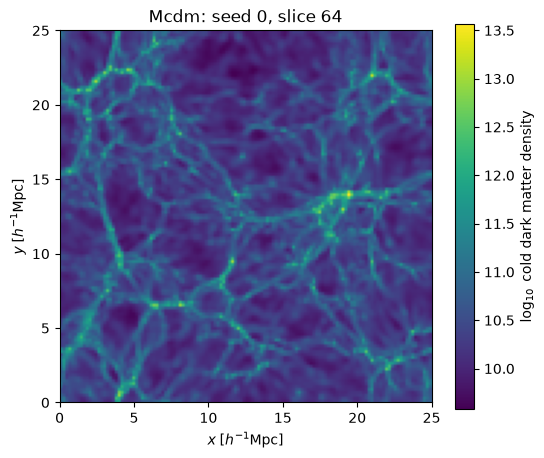

In [4]:
seed = 0
slice_number = 64
image = grids[seed, :, :, slice_number]

plt.figure(figsize=(6, 5))
plt.imshow(np.log10(image).T, origin="lower", extent=[0, 25, 0, 25])
plt.colorbar(label=r"$\log_{10}$ cold dark matter density")
plt.xlabel(r"$x\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$y\;[h^{-1}\mathrm{Mpc}]$")
plt.title(f"Mcdm: seed {seed}, slice {slice_number}")
plt.show()

## 5. Compare all fields for two seeds

We now repeat the same basic steps for seeds 0 and 1. Each column has its own colour scale and unit. Within a column, both seeds use the same colour limits, which makes their structures easier to compare.

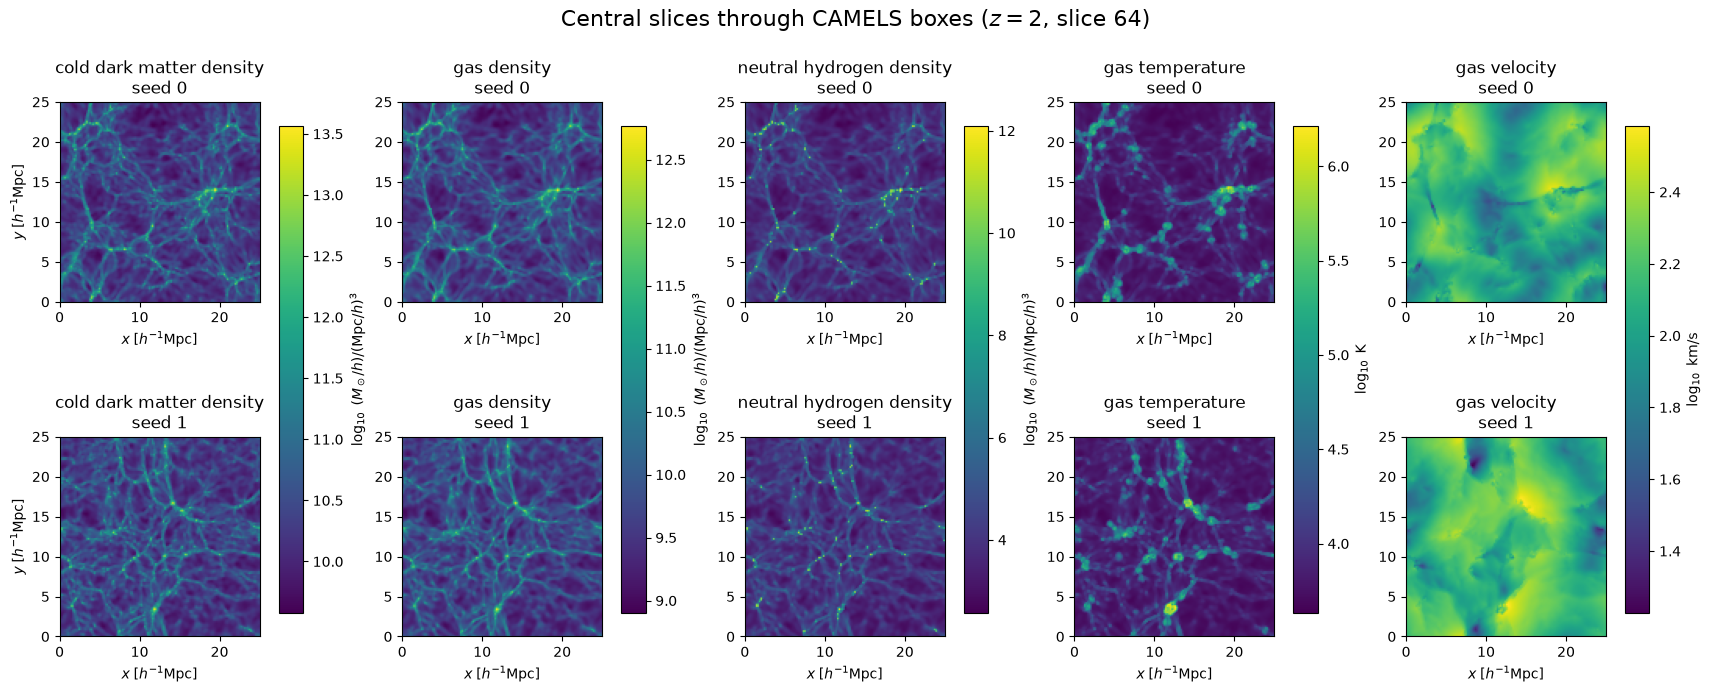

In [5]:
fields = {
    "Mcdm": ("cold dark matter density", r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$"),
    "Mgas": ("gas density", r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$"),
    "HI": ("neutral hydrogen density", r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$"),
    "T": ("gas temperature", "K"),
    "Vgas": ("gas velocity", "km/s"),
}

seeds = [0, 1]
slice_number = 64
fig, axes = plt.subplots(2, 5, figsize=(17, 7), constrained_layout=True)

for column, (field, (name, unit)) in enumerate(fields.items()):
    file = data_directory / f"Grids_{field}_IllustrisTNG_CV_128_z=2.0.npy"
    grids = np.load(file)

    images = []
    for seed in seeds:
        image = grids[seed, :, :, slice_number]
        images.append(np.log10(image).T)

    lower_limit = min(image.min() for image in images)
    upper_limit = max(image.max() for image in images)

    for row, seed in enumerate(seeds):
        plot = axes[row, column].imshow(
            images[row],
            origin="lower",
            extent=[0, 25, 0, 25],
            vmin=lower_limit,
            vmax=upper_limit,
        )
        axes[row, column].set_title(f"{name}\nseed {seed}")
        axes[row, column].set_xlabel(r"$x\;[h^{-1}\mathrm{Mpc}]$")
        if column == 0:
            axes[row, column].set_ylabel(r"$y\;[h^{-1}\mathrm{Mpc}]$")

    fig.colorbar(plot, ax=axes[:, column], shrink=0.75, label=rf"$\log_{{10}}$ {unit}")

fig.suptitle(f"Central slices through CAMELS boxes ($z=2$, slice {slice_number})", fontsize=16)
plt.show()

## 6. Save the comparison figure

The last figure is still stored in `fig`, so it can be saved without rebuilding it.

In [6]:
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)
fig.savefig(output_directory / "CAMELS_slices_seeds_0_1.png", dpi=150, bbox_inches="tight")

## Things to try

1. Change `seeds` to two other values between 0 and 26.
2. Change `slice_number` to any integer between 0 and 127.
3. Slice along a different axis. For example, `grids[seed, 64, :, :]` fixes the first spatial axis.
4. Remove `np.log10(...)` and observe why a linear colour scale hides much of the structure.

Remember that the box is periodic: opposite faces are neighbours in the simulation.